In [1]:
#Importing packages
import argparse
import os
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import numpy as np

from chromadb import PersistentClient as PersistentClient
from chromadb.errors import InternalError as CollectionError

#library functions
import helper_code.dataloading as dataloading
import helper_code.data_vis as data_vis
import helper_code.model_functions as model_functions

d:\Projects\alertcalifornia-anomaly-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.manual_seed(1234)

In [3]:
labels_csv = r"camera_data/coronado_hills_4pt_test_json.json"

device = 'cuda'

model_path = 'weights/'
model_name = "deepsad_init_model.pth"

data = dataloading.get_data(labels_csv, 'camera_data/images/', replace_images = False)
print("got all data")

train, val, test = dataloading.get_train_val_test(data = data, output_csvs=True)

train_dataset, val_dataset, test_dataset = dataloading.get_datasets(train, val, test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, pin_memory=True)

Got data
got columns
dataframe made


  9%|▊         | 643/7488 [01:36<17:05,  6.68it/s]  


KeyboardInterrupt: 

Text(0, 0.5, 'Proportion')

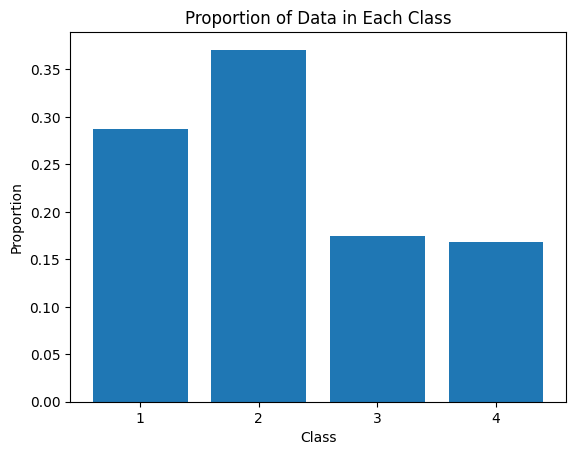

In [13]:
import matplotlib.pyplot as plt

plt.bar(np.sort((data['choice'] + 1).unique()), (data['choice'] + 1).value_counts().sort_index().to_numpy() / len(data))

plt.xticks([1,2,3,4])
plt.title("Proportion of Data in Each Class")
plt.xlabel("Class")
plt.ylabel("Proportion")

In [14]:
(data['choice'] + 1).value_counts().sort_index() / len(data)

choice
1    0.286806
2    0.370833
3    0.174306
4    0.168056
Name: count, dtype: float64